In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
import seaborn as sns
from tqdm import tqdm

from Greedy_SOSP import Greedy_SOSP

DATA_PATH = Path("data") / "delhi_road_drive.txt"
RESULTS_GSOSP_CSV = Path("delhi_road_drive_results_GSOSP.csv")

In [2]:
def load_roadnet_edges(path):
    """Read the RoadNet-CA directed edge list from the dataset file."""
    return pd.read_csv(
        path,
        sep=r"\s+",
        comment="#",
        header=None,
        names=["source", "target"],
        dtype={"source": int, "target": int},
    )


def build_subgraph(edge_df):
    """Build a directed graph from an edge DataFrame."""
    G = nx.DiGraph()
    G.add_edges_from(edge_df.itertuples(index=False, name=None))
    return G


edge_df = load_roadnet_edges(DATA_PATH)
print(f"Loaded {len(edge_df):,} edges from {DATA_PATH}")

Loaded 24,384 edges from data\delhi_road_drive.txt


In [3]:
EDGE_COUNTS = [5000, 10_000, 15_000, 20_000, len(edge_df)]
REPEAT = 5

results = []

total_runs = len(EDGE_COUNTS) * REPEAT
with tqdm(total=total_runs, desc="RoadNet-CA experiments") as pbar:
    for edges_count in EDGE_COUNTS:
        subset = edge_df.iloc[:edges_count]
        for trial in range(REPEAT):
            G = build_subgraph(subset)
            start = time.perf_counter()
            Greedy_SOSP(G)
            end = time.perf_counter()

            results.append({
                "edges": edges_count,
                "nodes": G.number_of_nodes(),
                "runtime": end - start,
                "trial": trial + 1,
            })
            pbar.update(1)


results_df = pd.DataFrame(results)
results_df.head()

RoadNet-CA experiments: 100%|██████████| 25/25 [00:01<00:00, 21.05it/s]


,edges,nodes,runtime,trial
0,5000,3966,0.005210,1
1,5000,3966,0.003930,2
2,5000,3966,0.007157,3
3,5000,3966,0.003879,4
4,5000,3966,0.003640,5


In [4]:
results_df.to_csv(RESULTS_GSOSP_CSV, index=False)
print(f"Saved runtime results to {RESULTS_GSOSP_CSV}")

Saved runtime results to delhi_road_drive_results_GSOSP.csv


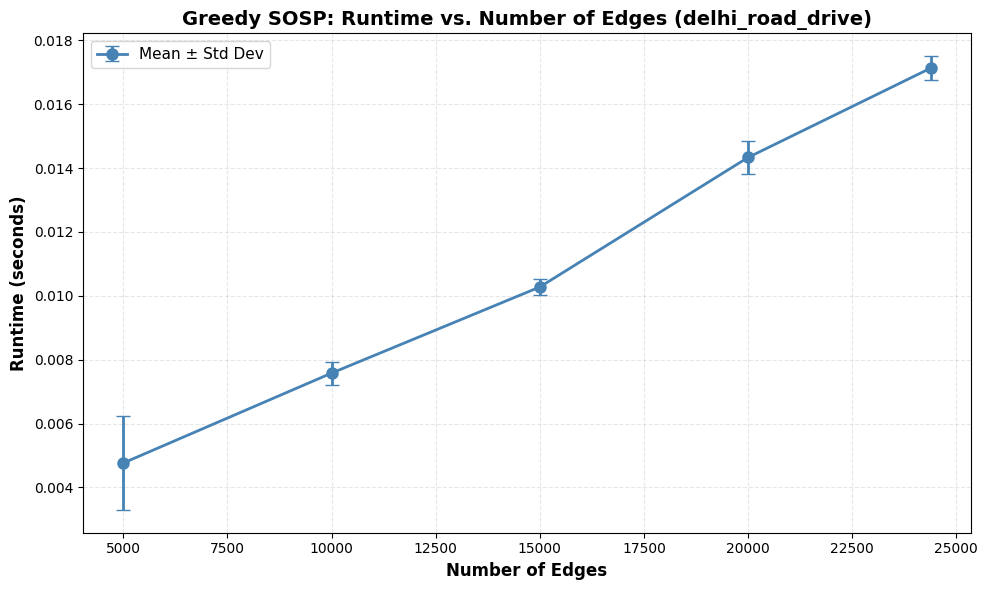


Runtime Statistics by Edges:
 edges     mean      std
  5000 0.004763 0.001472
 10000 0.007579 0.000357
 15000 0.010276 0.000251
 20000 0.014333 0.000529
 24384 0.017130 0.000380


In [11]:
# Load and plot runtime results for Greedy_SOSP
gsosp_results = pd.read_csv(RESULTS_GSOSP_CSV)

# Aggregate runtimes by edges (mean and std)
runtime_by_edges = gsosp_results.groupby('edges')['runtime'].agg(['mean', 'std']).reset_index()

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plot mean runtime with error bars
ax.errorbar(runtime_by_edges['edges'], runtime_by_edges['mean'], 
            yerr=runtime_by_edges['std'], marker='o', linewidth=2, 
            markersize=8, capsize=5, label='Mean ± Std Dev', color='steelblue')

# Formatting
ax.set_xlabel('Number of Edges', fontsize=12, fontweight='bold')
ax.set_ylabel('Runtime (seconds)', fontsize=12, fontweight='bold')
ax.set_title('Greedy SOSP: Runtime vs. Number of Edges (delhi_road_drive)', 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(fontsize=11)

# Use log scale for x-axis if there's a large range
if runtime_by_edges['edges'].max() / runtime_by_edges['edges'].min() > 50:
    ax.set_xscale('log')
    ax.set_xlabel('Number of Edges (log scale)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nRuntime Statistics by Edges:")
print(runtime_by_edges.to_string(index=False))

In [6]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
import seaborn as sns
from tqdm import tqdm
from Robust_MOSP import  Robust_MOSP

DATA_PATH = Path("data") / "delhi_road_drive.txt"
RESULTS_RMOSP_CSV = Path("delhi_road_drive_results_RMOSP.csv")

In [7]:
def load_roadnet_edges(path):
    """Read the RoadNet-CA directed edge list from the dataset file."""
    return pd.read_csv(
        path,
        sep=r"\s+",
        comment="#",
        header=None,
        names=["source", "target"],
        dtype={"source": int, "target": int},
    )


def build_subgraph(edge_df):
    """Build a directed graph from an edge DataFrame."""
    G = nx.DiGraph()
    G.add_edges_from(edge_df.itertuples(index=False, name=None))
    return G


edge_df = load_roadnet_edges(DATA_PATH)
print(f"Loaded {len(edge_df):,} edges from {DATA_PATH}")

Loaded 24,384 edges from data\delhi_road_drive.txt


In [8]:
EDGE_COUNTS = [5000, 10_000, 15_000, 20_000, len(edge_df)]
REPEAT = 5

results = []

total_runs = len(EDGE_COUNTS) * REPEAT
with tqdm(total=total_runs, desc="RoadNet-CA experiments") as pbar:
    for edges_count in EDGE_COUNTS:
        subset = edge_df.iloc[:edges_count]
        for trial in range(REPEAT):
            G = build_subgraph(subset)
            start = time.perf_counter()
            Robust_MOSP(G)
            end = time.perf_counter()

            results.append({
                "edges": edges_count,
                "nodes": G.number_of_nodes(),
                "runtime": end - start,
                "trial": trial + 1,
            })
            pbar.update(1)


results_df = pd.DataFrame(results)
results_df.head()

RoadNet-CA experiments: 100%|██████████| 25/25 [00:34<00:00,  1.39s/it]


,edges,nodes,runtime,trial
0,5000,3966,0.624123,1
1,5000,3966,0.642981,2
2,5000,3966,0.655228,3
3,5000,3966,0.571262,4
4,5000,3966,0.583366,5


In [9]:
results_df.to_csv(RESULTS_RMOSP_CSV, index=False)
print(f"Saved runtime results to {RESULTS_RMOSP_CSV}")

Saved runtime results to delhi_road_drive_results_RMOSP.csv


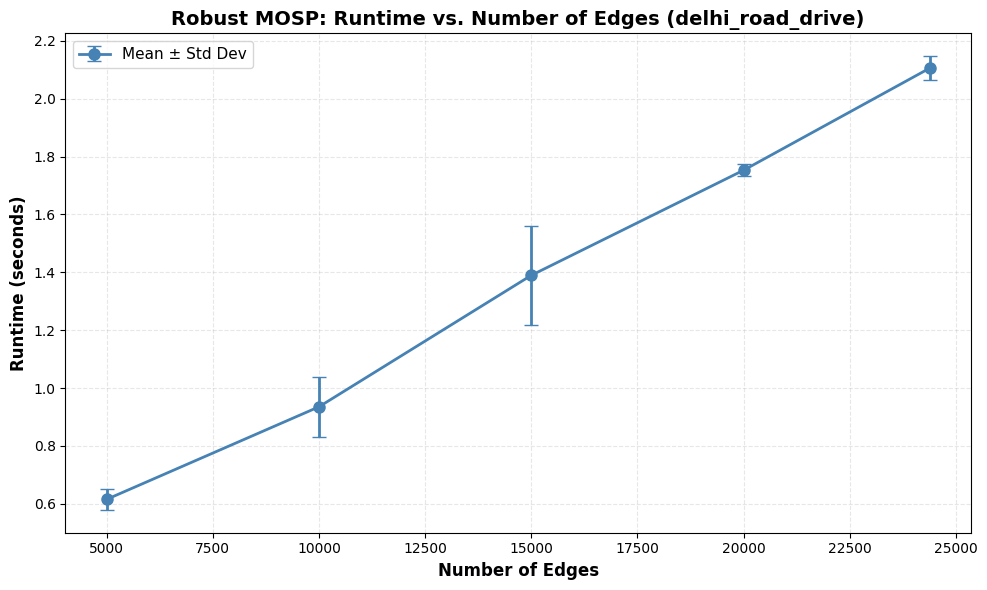


Runtime Statistics by Edges:
 edges     mean      std
  5000 0.615392 0.036733
 10000 0.935284 0.103968
 15000 1.389653 0.170331
 20000 1.752906 0.021494
 24384 2.105759 0.041709


In [10]:
# Load and plot runtime results for Greedy_SOSP
gsosp_results = pd.read_csv(RESULTS_RMOSP_CSV)

# Aggregate runtimes by edges (mean and std)
runtime_by_edges = gsosp_results.groupby('edges')['runtime'].agg(['mean', 'std']).reset_index()

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plot mean runtime with error bars
ax.errorbar(runtime_by_edges['edges'], runtime_by_edges['mean'], 
            yerr=runtime_by_edges['std'], marker='o', linewidth=2, 
            markersize=8, capsize=5, label='Mean ± Std Dev', color='steelblue')

# Formatting
ax.set_xlabel('Number of Edges', fontsize=12, fontweight='bold')
ax.set_ylabel('Runtime (seconds)', fontsize=12, fontweight='bold')
ax.set_title('Robust MOSP: Runtime vs. Number of Edges (delhi_road_drive)', 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(fontsize=11)

# Use log scale for x-axis if there's a large range
if runtime_by_edges['edges'].max() / runtime_by_edges['edges'].min() > 50:
    ax.set_xscale('log')
    ax.set_xlabel('Number of Edges (log scale)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nRuntime Statistics by Edges:")
print(runtime_by_edges.to_string(index=False))

**combined greedy sosp and robust mosp**

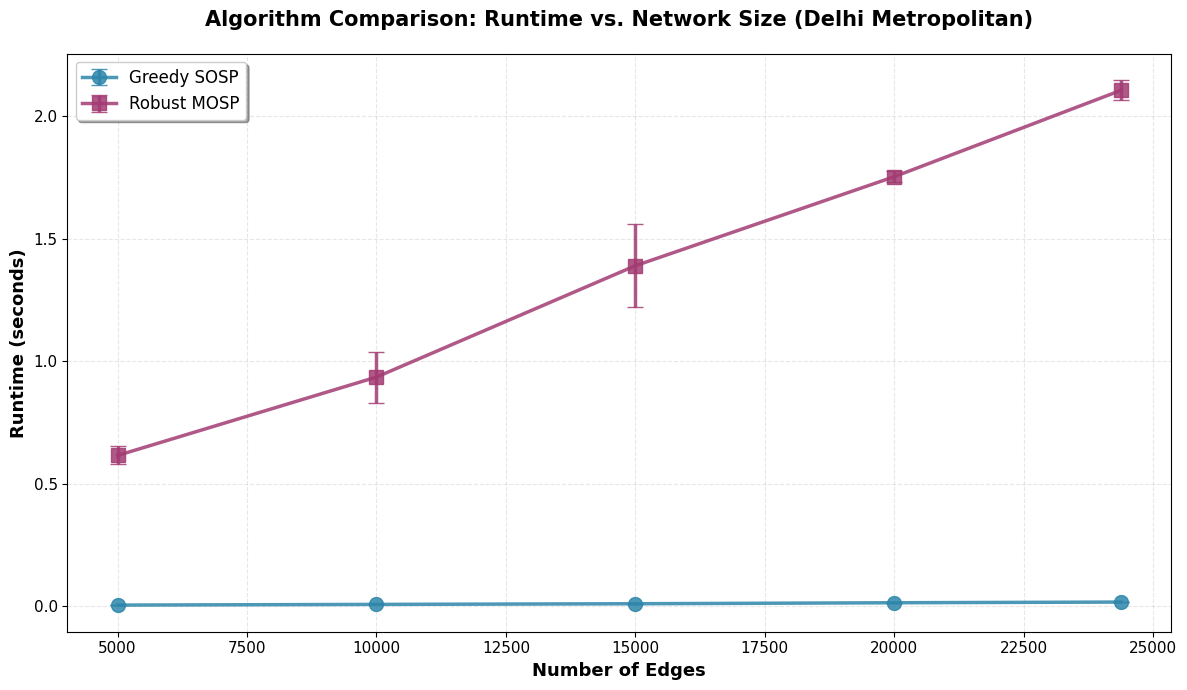

COMBINED ALGORITHM COMPARISON - Delhi Metropolitan

Greedy SOSP Runtime Statistics:
 edges     mean      std
  5000 0.004763 0.001472
 10000 0.007579 0.000357
 15000 0.010276 0.000251
 20000 0.014333 0.000529
 24384 0.017130 0.000380

Robust MOSP Runtime Statistics:
 edges     mean      std
  5000 0.615392 0.036733
 10000 0.935284 0.103968
 15000 1.389653 0.170331
 20000 1.752906 0.021494
 24384 2.105759 0.041709

SPEEDUP ANALYSIS (Robust MOSP / Greedy SOSP):
Edges:   5000 | Speedup:   129.19x
Edges:  10000 | Speedup:   123.41x
Edges:  15000 | Speedup:   135.23x
Edges:  20000 | Speedup:   122.30x
Edges:  24384 | Speedup:   122.93x


In [1]:
# Combined plot: Greedy SOSP vs Robust MOSP on RoadNet-CA
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Define paths
RESULTS_GSOSP_CSV = Path("delhi_road_drive_results_GSOSP.csv")
RESULTS_RMOSP_CSV = Path("delhi_road_drive_results_RMOSP.csv")

# Load results from both algorithms
gsosp_results = pd.read_csv(RESULTS_GSOSP_CSV)
rmosp_results = pd.read_csv(RESULTS_RMOSP_CSV)

# Aggregate runtimes by edges (mean and std)
gsosp_runtime = gsosp_results.groupby('edges')['runtime'].agg(['mean', 'std']).reset_index()
gsosp_runtime['algorithm'] = 'Greedy SOSP'

rmosp_runtime = rmosp_results.groupby('edges')['runtime'].agg(['mean', 'std']).reset_index()
rmosp_runtime['algorithm'] = 'Robust MOSP'

# Create the combined plot
fig, ax = plt.subplots(figsize=(12, 7))

# Plot Greedy SOSP
ax.errorbar(gsosp_runtime['edges'], gsosp_runtime['mean'], 
            yerr=gsosp_runtime['std'], marker='o', linewidth=2.5, 
            markersize=10, capsize=6, label='Greedy SOSP', 
            color='#2E86AB', alpha=0.85)

# Plot Robust MOSP
ax.errorbar(rmosp_runtime['edges'], rmosp_runtime['mean'], 
            yerr=rmosp_runtime['std'], marker='s', linewidth=2.5, 
            markersize=10, capsize=6, label='Robust MOSP', 
            color='#A23B72', alpha=0.85)

# Formatting for research paper
ax.set_xlabel('Number of Edges', fontsize=13, fontweight='bold')
ax.set_ylabel('Runtime (seconds)', fontsize=13, fontweight='bold')
ax.set_title('Algorithm Comparison: Runtime vs. Network Size (Delhi Metropolitan)', 
             fontsize=15, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)
ax.legend(fontsize=12, loc='upper left', frameon=True, shadow=True)

# Add tick formatting
ax.tick_params(axis='both', which='major', labelsize=11)

plt.tight_layout()
# plt.savefig('roadNet-CA_combined_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Print comparison statistics
print("=" * 70)
print("COMBINED ALGORITHM COMPARISON - Delhi Metropolitan")
print("=" * 70)
print("\nGreedy SOSP Runtime Statistics:")
print(gsosp_runtime[['edges', 'mean', 'std']].to_string(index=False))
print("\nRobust MOSP Runtime Statistics:")
print(rmosp_runtime[['edges', 'mean', 'std']].to_string(index=False))

# Calculate speedup
print("\n" + "=" * 70)
print("SPEEDUP ANALYSIS (Robust MOSP / Greedy SOSP):")
print("=" * 70)
for edges in gsosp_runtime['edges']:
    gsosp_mean = gsosp_runtime[gsosp_runtime['edges'] == edges]['mean'].values[0]
    rmosp_mean = rmosp_runtime[rmosp_runtime['edges'] == edges]['mean'].values[0]
    speedup = rmosp_mean / gsosp_mean
    print(f"Edges: {edges:>6} | Speedup: {speedup:>8.2f}x")